# YOLOv7 vs YOLOv9 vs YOLOv11 Comparison Notebook

Notebook ini membandingkan tiga model yang sudah ditraining (YOLOv7, YOLOv9, YOLOv11) dalam satu pipeline terpadu:

1. Ambil run terbaik terbaru untuk masing-masing model
2. Ringkas semua metrik evaluasi utama (Precision, Recall, mAP@0.5, mAP@0.5:0.95, F1, accuracy proxy)
3. Tampilkan kurva dan artefak evaluasi
4. Jalankan inference baru pada sample gambar validasi
5. Hitung deviasi ukuran hasil inference terhadap ground truth dalam mm

Catatan penting:
- Untuk object detection, metrik accuracy klasik tidak umum dipakai.
- Notebook ini menambahkan **accuracy proxy** untuk deteksi: TP/(TP+FP+FN).
- Konversi pixel ke mm menggunakan asumsi diameter aktual **ab disk = 6.0 mm** sebagai skala kalibrasi per gambar.

In [1]:
import os
import sys
import math
import random
import shutil
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from IPython.display import display
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = Path.cwd().parent if Path.cwd().name == "scripts" else Path.cwd()
YOLO_DIR = BASE_DIR / "dataset" / "yolo_format"
VAL_IMG_DIR = YOLO_DIR / "images" / "val"
VAL_LABEL_DIR = YOLO_DIR / "labels" / "val"

Y7_REPO = BASE_DIR / "external" / "yolov7"
Y9_REPO = BASE_DIR / "external" / "yolov9"
Y11_RUNS = BASE_DIR / "outputs" / "yolov11_preparation" / "yolov11_runs"

OUTPUT_ROOT = BASE_DIR / "outputs" / "model_comparison"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["ab disk", "inhibition zone"]
CLASS_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}
AB_DISK_DIAMETER_MM = 6.0

print(f"BASE_DIR     : {BASE_DIR}")
print(f"YOLO_DIR     : {YOLO_DIR}")
print(f"VAL_IMG_DIR  : {VAL_IMG_DIR}")
print(f"VAL_LABEL_DIR: {VAL_LABEL_DIR}")
print(f"Y7_REPO      : {Y7_REPO}")
print(f"Y9_REPO      : {Y9_REPO}")
print(f"Y11_RUNS     : {Y11_RUNS}")
print(f"OUTPUT_ROOT  : {OUTPUT_ROOT}")

BASE_DIR     : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram
YOLO_DIR     : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\dataset\yolo_format
VAL_IMG_DIR  : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\dataset\yolo_format\images\val
VAL_LABEL_DIR: c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\dataset\yolo_format\labels\val
Y7_REPO      : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov7
Y9_REPO      : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov9
Y11_RUNS     : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\yolov11_preparation\yolov11_runs
OUTPUT_ROOT  : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\model_comparison


In [2]:
def latest_dir(base_dir: Path, pattern: str):
    dirs = sorted([d for d in base_dir.glob(pattern) if d.is_dir()], key=lambda x: x.stat().st_mtime, reverse=True)
    return dirs[0] if dirs else None

y7_train_dir = latest_dir(Y7_REPO / "runs" / "train", "antibiogram_*")
y9_train_dir = latest_dir(Y9_REPO / "runs" / "train", "antibiogram_*")
y11_train_dir = latest_dir(Y11_RUNS, "antibiogram_yolo11*")

if y7_train_dir is None or y9_train_dir is None:
    raise FileNotFoundError("Run training folder tidak ditemukan untuk salah satu model.")

y7_best = y7_train_dir / "weights" / "best.pt"
y9_best = y9_train_dir / "weights" / "best.pt"

if not y7_best.exists() or not y9_best.exists():
    raise FileNotFoundError("best.pt tidak ditemukan pada salah satu run model.")

y7_results_txt = y7_train_dir / "results.txt"
y9_results_csv = y9_train_dir / "results.csv"

y11_best = None
y11_results_csv = None
if y11_train_dir is not None:
    y11_best = y11_train_dir / "weights" / "best.pt"
    y11_results_csv = y11_train_dir / "results.csv"
    if not y11_best.exists():
        print("Warning: YOLOv11 best.pt not found in latest run. YOLOv11 will be skipped.")
        y11_best = None
else:
    print("Warning: YOLOv11 run not found. YOLOv11 will be skipped.")

print("Selected runs")
print(f"YOLOv7 run      : {y7_train_dir.name}")
print(f"YOLOv7 best     : {y7_best}")
print(f"YOLOv7 results  : {y7_results_txt}")
print()
print(f"YOLOv9 run      : {y9_train_dir.name}")
print(f"YOLOv9 best     : {y9_best}")
print(f"YOLOv9 results  : {y9_results_csv}")
print()
if y11_train_dir is not None:
    print(f"YOLOv11 run     : {y11_train_dir.name}")
    print(f"YOLOv11 best    : {y11_best if y11_best else 'not found'}")
    print(f"YOLOv11 results : {y11_results_csv if y11_results_csv else 'not found'}")
    print()

print(f"YOLOv7 size (MB): {y7_best.stat().st_size / (1024*1024):.2f}")
print(f"YOLOv9 size (MB): {y9_best.stat().st_size / (1024*1024):.2f}")
if y11_best is not None and y11_best.exists():
    print(f"YOLOv11 size (MB): {y11_best.stat().st_size / (1024*1024):.2f}")

Selected runs
YOLOv7 run      : antibiogram_improved_640
YOLOv7 best     : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov7\runs\train\antibiogram_improved_640\weights\best.pt
YOLOv7 results  : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov7\runs\train\antibiogram_improved_640\results.txt

YOLOv9 run      : antibiogram_yolov9_clean
YOLOv9 best     : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov9\runs\train\antibiogram_yolov9_clean\weights\best.pt
YOLOv9 results  : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov9\runs\train\antibiogram_yolov9_clean\results.csv

YOLOv11 run     : antibiogram_yolo11_stage2_plus
YOLOv11 best    : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\yolov11_preparation\yolov11_runs\antibiogram_yolo11_stage2_plus\weights\best.pt
YOLOv11 results : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\yolov11_preparation\yolov11_runs\antibiogram_yolo11_stage2_plus\results.csv

YOLOv7 size (MB): 71.33
YOLOv9 siz

In [3]:
def detection_f1(p: float, r: float) -> float:
    return (2 * p * r / (p + r)) if (p + r) > 0 else 0.0

def detection_accuracy_proxy(p: float, r: float) -> float:
    # Accuracy proxy for detection: TP / (TP + FP + FN)
    f1 = detection_f1(p, r)
    return (f1 / (2 - f1)) if f1 < 1.999 else 0.0

def parse_yolov9_metrics(csv_path: Path):
    df = pd.read_csv(csv_path)
    if df.empty:
        raise ValueError(f"Empty file: {csv_path}")

    df.columns = [str(c).strip() for c in df.columns]

    def pick_col(candidates):
        for c in candidates:
            if c in df.columns:
                return c

        norm_map = {
            str(c).lower().replace(" ", "").replace("_", "").replace("(b)", ""): c
            for c in df.columns
        }
        for c in candidates:
            key = str(c).lower().replace(" ", "").replace("_", "").replace("(b)", "")
            if key in norm_map:
                return norm_map[key]
        return None

    epoch_col = pick_col(["epoch"])
    prec_col = pick_col(["metrics/precision(B)", "metrics/precision"])
    rec_col = pick_col(["metrics/recall(B)", "metrics/recall"])
    map50_col = pick_col(["metrics/mAP50(B)", "metrics/mAP_0.5", "metrics/mAP50", "metrics/mAP@0.5"])
    map5095_col = pick_col(["metrics/mAP50-95(B)", "metrics/mAP_0.5:0.95", "metrics/mAP50-95", "metrics/mAP@0.5:0.95"])

    if epoch_col is None:
        df["epoch_auto"] = range(len(df))
        epoch_col = "epoch_auto"

    std = pd.DataFrame({
        "epoch": df[epoch_col].astype(int),
        "precision": df[prec_col].astype(float) if prec_col else 0.0,
        "recall": df[rec_col].astype(float) if rec_col else 0.0,
        "map50": df[map50_col].astype(float) if map50_col else 0.0,
        "map5095": df[map5095_col].astype(float) if map5095_col else 0.0,
    })

    return std

def parse_yolov7_metrics(results_txt_path: Path):
    lines = [ln.strip() for ln in results_txt_path.read_text(encoding="utf-8", errors="ignore").splitlines() if ln.strip()]

    rows = []
    for ln in lines:
        parts = ln.split()
        if len(parts) < 15:
            continue
        if "/" not in parts[0]:
            continue

        ep_cur, ep_total = parts[0].split("/", 1)

        try:
            rows.append({
                "epoch": int(ep_cur),
                "epoch_total": int(ep_total),
                "precision": float(parts[8]),
                "recall": float(parts[9]),
                "map50": float(parts[10]),
                "map5095": float(parts[11]),
            })
        except Exception:
            continue

    if not rows:
        raise ValueError(f"Could not parse metrics from: {results_txt_path}")

    return pd.DataFrame(rows)

y7_curve = parse_yolov7_metrics(y7_results_txt)
y9_curve = parse_yolov9_metrics(y9_results_csv)

y11_curve = None
if "y11_results_csv" in globals() and y11_results_csv is not None and y11_results_csv.exists():
    y11_curve = parse_yolov9_metrics(y11_results_csv)
else:
    print("YOLOv11 results.csv not found; skipping YOLOv11 metrics.")

def best_and_latest(df_curve: pd.DataFrame):
    latest = df_curve.iloc[-1]
    best_map50 = df_curve.loc[df_curve["map50"].idxmax()]
    best_map5095 = df_curve.loc[df_curve["map5095"].idxmax()]
    return latest, best_map50, best_map5095

y7_latest, y7_best50, y7_best5095 = best_and_latest(y7_curve)
y9_latest, y9_best50, y9_best5095 = best_and_latest(y9_curve)

summary_rows = []
for model_name, row_name, row in [
    ("YOLOv7", "latest", y7_latest),
    ("YOLOv7", "best mAP@0.5", y7_best50),
    ("YOLOv7", "best mAP@0.5:0.95", y7_best5095),
    ("YOLOv9", "latest", y9_latest),
    ("YOLOv9", "best mAP@0.5", y9_best50),
    ("YOLOv9", "best mAP@0.5:0.95", y9_best5095),
]:
    p = float(row["precision"])
    r = float(row["recall"])
    f1 = detection_f1(p, r)
    acc = detection_accuracy_proxy(p, r)

    summary_rows.append({
        "model": model_name,
        "checkpoint": row_name,
        "epoch": int(row["epoch"]),
        "precision": p,
        "recall": r,
        "mAP@0.5": float(row["map50"]),
        "mAP@0.5:0.95": float(row["map5095"]),
        "F1": f1,
        "Eval accuracy*": acc,
    })

if y11_curve is not None:
    y11_latest, y11_best50, y11_best5095 = best_and_latest(y11_curve)
    for model_name, row_name, row in [
        ("YOLOv11", "latest", y11_latest),
        ("YOLOv11", "best mAP@0.5", y11_best50),
        ("YOLOv11", "best mAP@0.5:0.95", y11_best5095),
    ]:
        p = float(row["precision"])
        r = float(row["recall"])
        f1 = detection_f1(p, r)
        acc = detection_accuracy_proxy(p, r)

        summary_rows.append({
            "model": model_name,
            "checkpoint": row_name,
            "epoch": int(row["epoch"]),
            "precision": p,
            "recall": r,
            "mAP@0.5": float(row["map50"]),
            "mAP@0.5:0.95": float(row["map5095"]),
            "F1": f1,
            "Eval accuracy*": acc,
        })

comparison_df = pd.DataFrame(summary_rows)
for c in ["precision", "recall", "mAP@0.5", "mAP@0.5:0.95", "F1", "Eval accuracy*"]:
    comparison_df[c] = comparison_df[c].map(lambda v: round(float(v), 4))

print("Evaluation comparison table")
display(comparison_df)
print("*Eval accuracy = TP/(TP+FP+FN) derived from precision-recall pair")

Evaluation comparison table


,model,checkpoint,epoch,precision,recall,mAP@0.5,mAP@0.5:0.95,F1,Eval accuracy*
0,YOLOv7,latest,179,0.9478,0.7850,0.8379,0.6942,0.8588,0.7525
1,YOLOv7,best mAP@0.5,145,0.9253,0.8032,0.8422,0.6893,0.8599,0.7543
2,YOLOv7,best mAP@0.5:0.95,176,0.9460,0.7913,0.8397,0.6987,0.8618,0.7571
3,YOLOv9,latest,179,0.9682,0.7405,0.8264,0.7236,0.8392,0.7229
4,YOLOv9,best mAP@0.5,164,0.9487,0.7769,0.8503,0.7353,0.8542,0.7456
5,YOLOv9,best mAP@0.5:0.95,156,0.9574,0.7802,0.8422,0.7369,0.8598,0.7540
6,YOLOv11,latest,174,0.9347,0.7827,0.8095,0.7128,0.8520,0.7421
7,YOLOv11,best mAP@0.5,13,0.9514,0.7680,0.8387,0.7091,0.8499,0.7390
8,YOLOv11,best mAP@0.5:0.95,114,0.9441,0.7852,0.8207,0.7155,0.8574,0.7504


*Eval accuracy = TP/(TP+FP+FN) derived from precision-recall pair


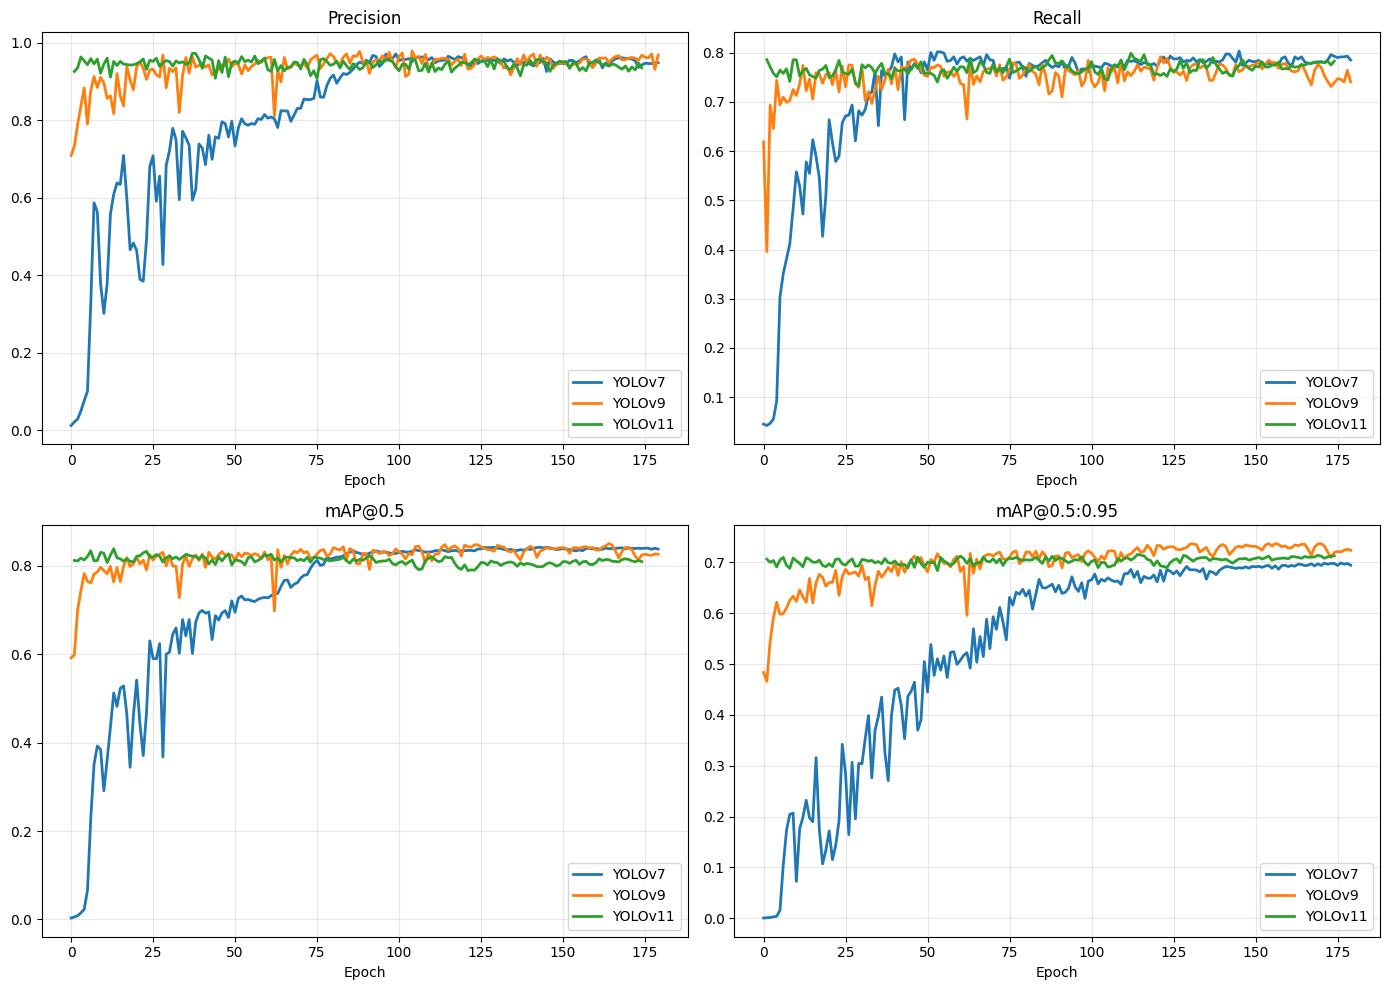

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("map50", "mAP@0.5"),
    ("map5095", "mAP@0.5:0.95"),
]

for ax, (col, title) in zip(axes.flat, metrics):
    ax.plot(y7_curve["epoch"], y7_curve[col], label="YOLOv7", linewidth=2)
    ax.plot(y9_curve["epoch"], y9_curve[col], label="YOLOv9", linewidth=2)
    if "y11_curve" in globals() and y11_curve is not None:
        ax.plot(y11_curve["epoch"], y11_curve[col], label="YOLOv11", linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

YOLOv7 eval dir: c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov7\runs\test\eval_final5
YOLOv9 eval dir: c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov9\runs\val\eval_yolov9_clean4


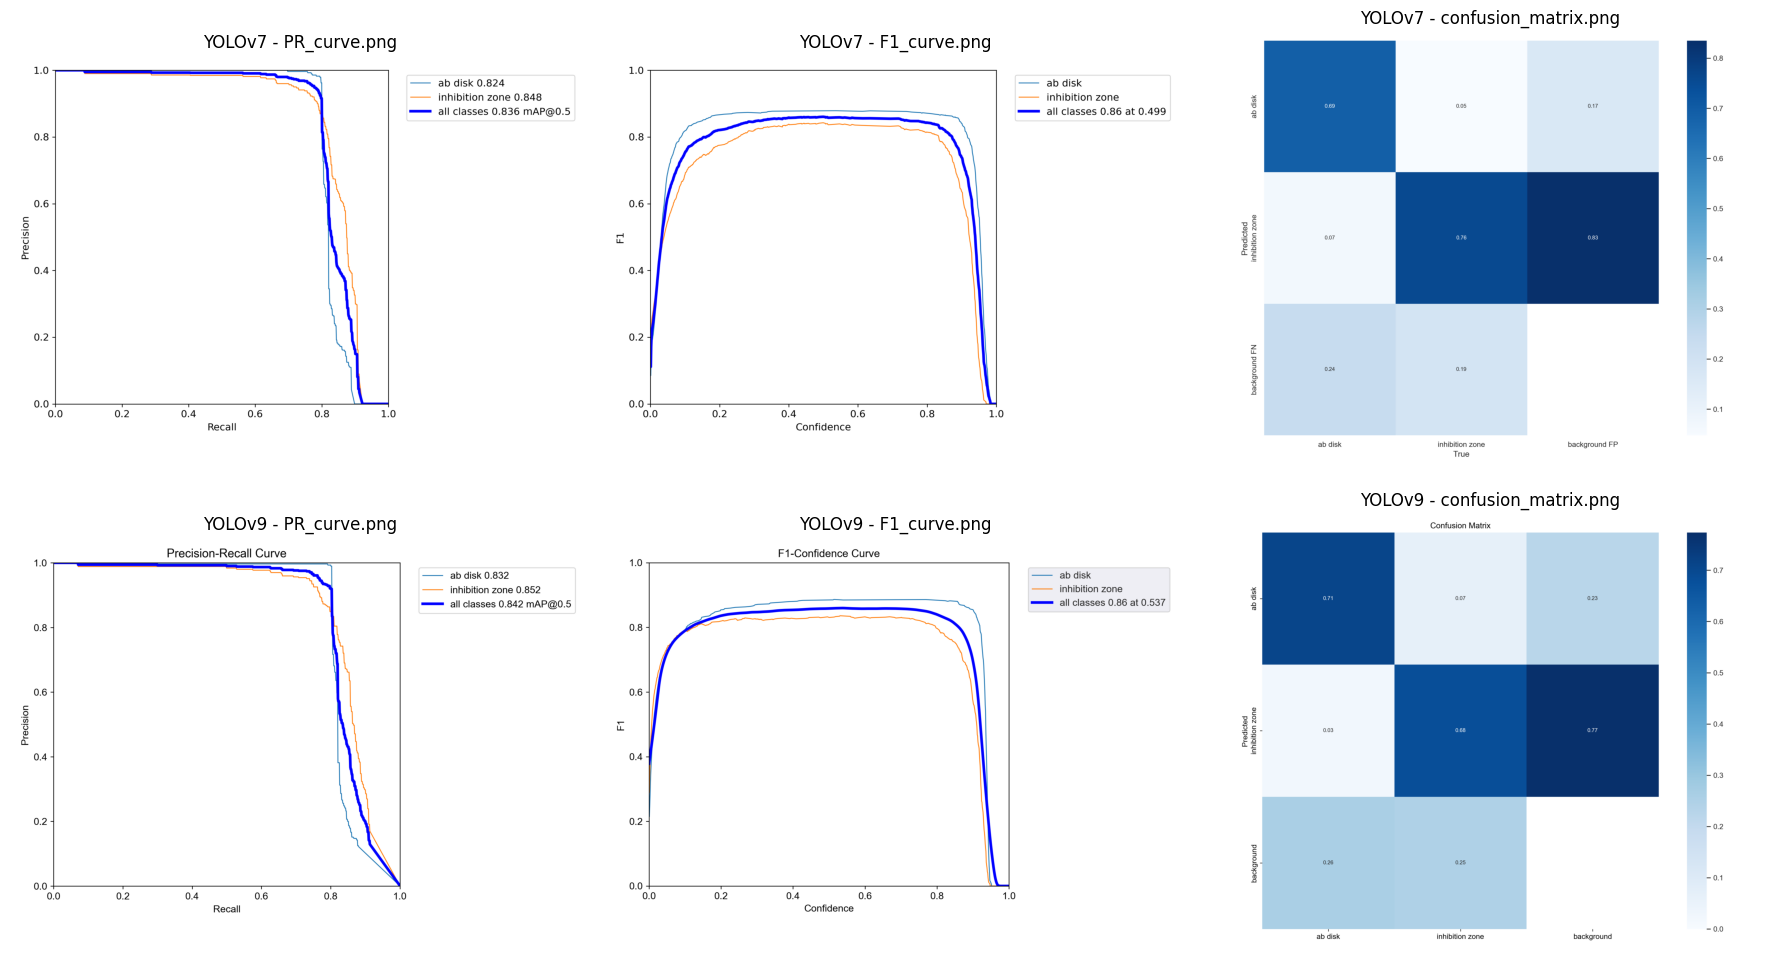

In [5]:
def latest_eval_dir(base_dir: Path, pattern: str):
    dirs = sorted([d for d in base_dir.glob(pattern) if d.is_dir()], key=lambda x: x.stat().st_mtime, reverse=True)
    return dirs[0] if dirs else None

y7_eval_dir = latest_eval_dir(Y7_REPO / "runs" / "test", "eval_final*")
y9_eval_dir = latest_eval_dir(Y9_REPO / "runs" / "val", "eval_yolov9_clean*")

print(f"YOLOv7 eval dir: {y7_eval_dir}")
print(f"YOLOv9 eval dir: {y9_eval_dir}")

artifact_names = ["PR_curve.png", "F1_curve.png", "confusion_matrix.png"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, fname in enumerate(artifact_names):
    ax = axes[0, i]
    p = (y7_eval_dir / fname) if y7_eval_dir else None
    if p and p.exists():
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"YOLOv7 - {fname}")
    else:
        ax.text(0.5, 0.5, f"{fname} not found", ha="center", va="center")
    ax.axis("off")

for i, fname in enumerate(artifact_names):
    ax = axes[1, i]
    p = (y9_eval_dir / fname) if y9_eval_dir else None
    if p and p.exists():
        img = Image.open(p).convert("RGB")
        ax.imshow(img)
        ax.set_title(f"YOLOv9 - {fname}")
    else:
        ax.text(0.5, 0.5, f"{fname} not found", ha="center", va="center")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
RUN_NEW_INFERENCE = True
SAMPLE_COUNT = 12
CONF_THRES = 0.25
IOU_THRES = 0.45
IMG_SIZE = 640

if not VAL_IMG_DIR.exists():
    raise FileNotFoundError(f"Validation image directory not found: {VAL_IMG_DIR}")

all_val_images = sorted(VAL_IMG_DIR.glob("*.jpg"))
if len(all_val_images) == 0:
    raise RuntimeError("Tidak ada image validasi (*.jpg) untuk inference baru.")

sample_count = min(SAMPLE_COUNT, len(all_val_images))
sample_images = random.sample(all_val_images, sample_count)

sample_dir = OUTPUT_ROOT / "inference_samples"
sample_dir.mkdir(parents=True, exist_ok=True)
for f in sample_dir.glob("*"):
    if f.is_file():
        f.unlink()

for src in sample_images:
    shutil.copy2(src, sample_dir / src.name)

print(f"Prepared {sample_count} new inference samples in: {sample_dir}")

def run_detect_with_fallback(repo_dir: Path, script_name: str, weights: Path, source: Path, run_name: str, device: str):
    img_flags = [["--img", str(IMG_SIZE)], ["--img-size", str(IMG_SIZE)]]
    conf_flags = [["--conf-thres", str(CONF_THRES)], ["--conf", str(CONF_THRES)]]

    attempts = []
    for img_flag in img_flags:
        for conf_flag in conf_flags:
            cmd = [
                sys.executable,
                str(repo_dir / script_name),
                "--weights", str(weights),
                "--source", str(source),
                *img_flag,
                *conf_flag,
                "--iou-thres", str(IOU_THRES),
                "--device", device,
                "--save-txt",
                "--save-conf",
                "--name", run_name,
                "--exist-ok",
            ]

            proc = subprocess.run(cmd, cwd=str(repo_dir), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, encoding="utf-8", errors="replace")
            attempts.append((cmd, proc.returncode, proc.stdout[-1200:]))

            if proc.returncode == 0:
                return cmd, proc

    # If all attempts fail, print compact debug.
    print("All detect command variants failed. Last outputs:")
    for i, (cmd, code, tail) in enumerate(attempts, 1):
        print(f"Attempt {i}, exit={code}: {' '.join(cmd)}")
        print(tail)

    raise RuntimeError("Failed to run detect.py with available argument variants.")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
Y7_INFER_RUN = f"cmp_y7_{timestamp}"
Y9_INFER_RUN = f"cmp_y9_{timestamp}"
Y11_INFER_RUN = None

device_arg = "0" if ("torch" in globals() and torch.cuda.is_available()) else "cpu"

if RUN_NEW_INFERENCE:
    y7_cmd, y7_proc = run_detect_with_fallback(
        repo_dir=Y7_REPO,
        script_name="detect.py",
        weights=y7_best,
        source=sample_dir,
        run_name=Y7_INFER_RUN,
        device=device_arg,
    )

    y9_cmd, y9_proc = run_detect_with_fallback(
        repo_dir=Y9_REPO,
        script_name="detect.py",
        weights=y9_best,
        source=sample_dir,
        run_name=Y9_INFER_RUN,
        device=device_arg,
    )

    print("YOLOv7 detect command:")
    print(' '.join(y7_cmd))
    print()
    print("YOLOv9 detect command:")
    print(' '.join(y9_cmd))

Y7_INFER_DIR = Y7_REPO / "runs" / "detect" / Y7_INFER_RUN
Y9_INFER_DIR = Y9_REPO / "runs" / "detect" / Y9_INFER_RUN
Y11_INFER_DIR = None

print()
print(f"YOLOv7 inference dir: {Y7_INFER_DIR}")
print(f"YOLOv9 inference dir: {Y9_INFER_DIR}")

if RUN_NEW_INFERENCE and "y11_best" in globals() and y11_best is not None and y11_best.exists():
    try:
        from ultralytics import YOLO
    except Exception as exc:
        print(f"Ultralytics not available for YOLOv11 inference: {exc}")
    else:
        y11_project = OUTPUT_ROOT / "yolov11_inference"
        Y11_INFER_RUN = f"cmp_y11_{timestamp}"
        model = YOLO(str(y11_best))
        model.predict(
            source=str(sample_dir),
            imgsz=IMG_SIZE,
            conf=CONF_THRES,
            iou=IOU_THRES,
            device=device_arg,
            save=True,
            save_txt=True,
            save_conf=True,
            project=str(y11_project),
            name=Y11_INFER_RUN,
            exist_ok=True,
        )
        Y11_INFER_DIR = y11_project / Y11_INFER_RUN
        print(f"YOLOv11 inference dir: {Y11_INFER_DIR}")
else:
    print("YOLOv11 inference skipped (best.pt not found or inference disabled).")

Prepared 12 new inference samples in: c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\model_comparison\inference_samples
YOLOv7 detect command:
c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\.venv\Scripts\python.exe c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov7\detect.py --weights c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov7\runs\train\antibiogram_improved_640\weights\best.pt --source c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\model_comparison\inference_samples --img 640 --conf-thres 0.25 --iou-thres 0.45 --device 0 --save-txt --save-conf --name cmp_y7_20260512_213650 --exist-ok

YOLOv9 detect command:
c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\.venv\Scripts\python.exe c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov9\detect.py --weights c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\external\yolov9\runs\train\antibiogram_yolov9_clean\weights\best.pt --source c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\model_comparison\inf

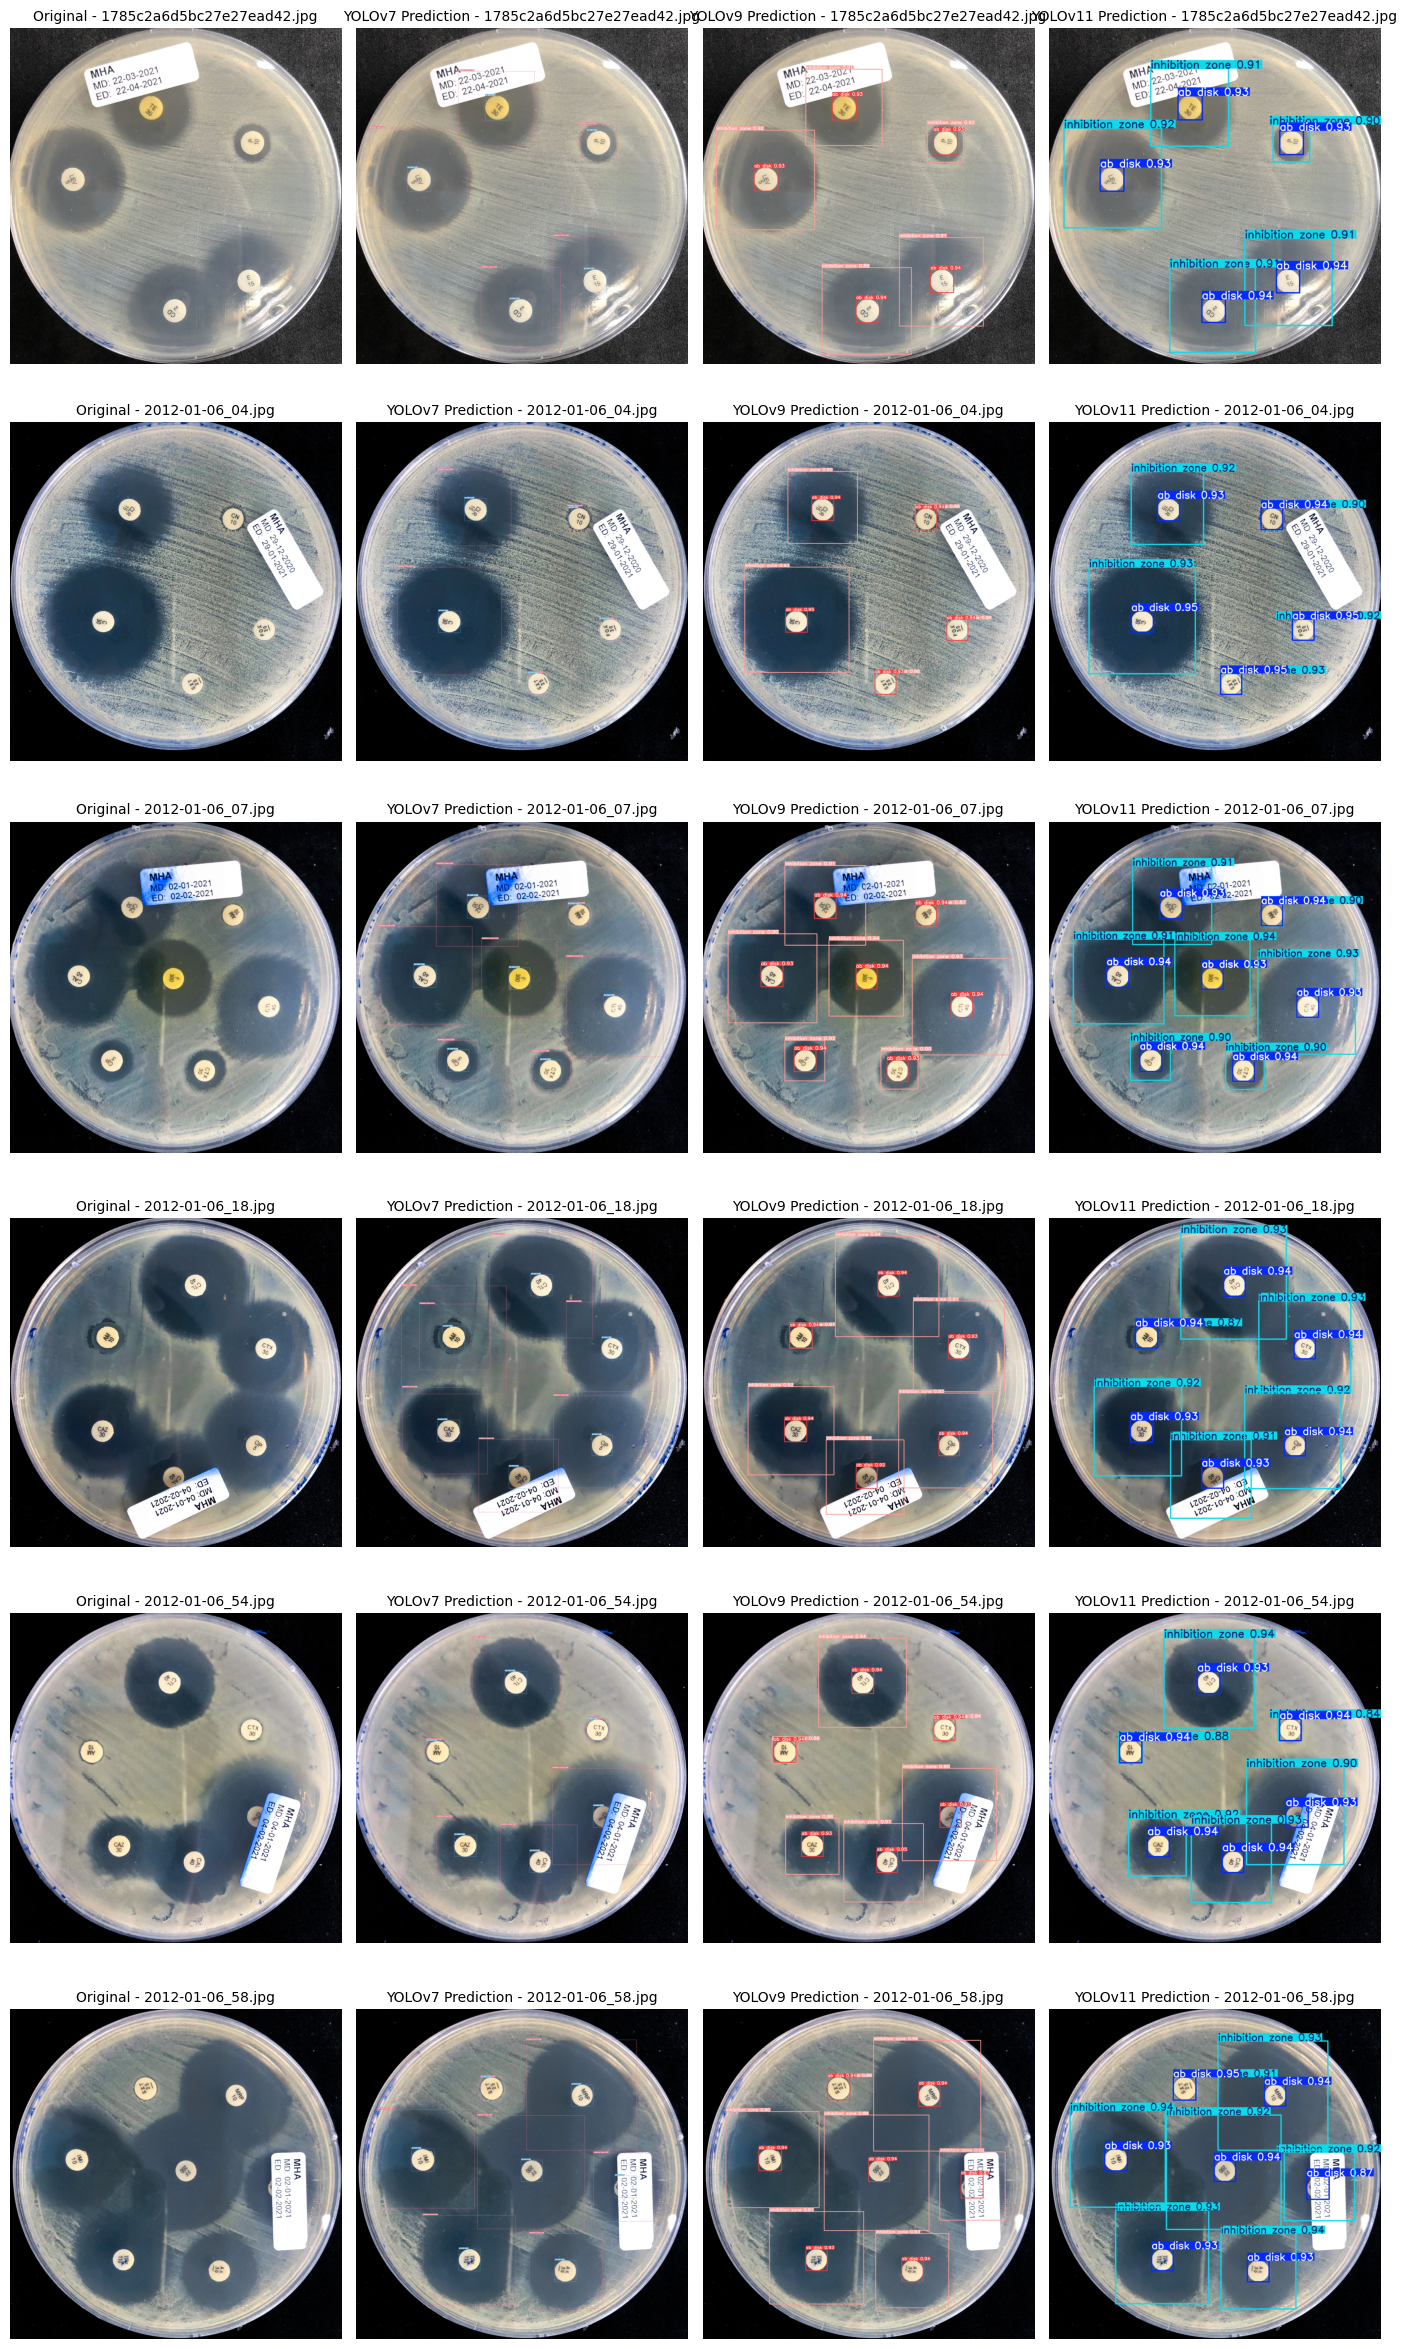

In [7]:
# Visual comparison: original vs predictions
display_files = sorted([p.name for p in sample_dir.glob("*.jpg")])[:6]

if len(display_files) == 0:
    print("No sample images found for visualization.")
else:
    use_y11 = "Y11_INFER_DIR" in globals() and Y11_INFER_DIR is not None and Y11_INFER_DIR.exists()
    cols = 4 if use_y11 else 3
    fig, axes = plt.subplots(len(display_files), cols, figsize=(14, 4 * len(display_files)))
    if len(display_files) == 1:
        axes = np.array([axes])

    for i, fname in enumerate(display_files):
        original_path = sample_dir / fname
        y7_path = Y7_INFER_DIR / fname
        y9_path = Y9_INFER_DIR / fname

        items = [
            ("Original", original_path),
            ("YOLOv7 Prediction", y7_path),
            ("YOLOv9 Prediction", y9_path),
        ]
        if use_y11:
            y11_path = Y11_INFER_DIR / fname
            items.append(("YOLOv11 Prediction", y11_path))

        for j, (title, path) in enumerate(items):
            ax = axes[i, j]
            if path.exists():
                ax.imshow(Image.open(path).convert("RGB"))
                ax.set_title(f"{title} - {fname}", fontsize=10)
            else:
                ax.text(0.5, 0.5, "image not found", ha="center", va="center")
                ax.set_title(f"{title} - {fname}", fontsize=10)
            ax.axis("off")

    plt.tight_layout()

In [8]:
def load_yolo_labels(label_path: Path, conf_default=1.0):
    records = []
    if not label_path.exists():
        return records

    for line in label_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        try:
            cls_id = int(float(parts[0]))
            x, y, w, h = map(float, parts[1:5])
            conf = float(parts[5]) if len(parts) > 5 else conf_default
            records.append({
                "class_id": cls_id,
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "conf": conf,
            })
        except Exception:
            continue

    return records

def to_pixel_box(item, img_w, img_h):
    cx = item["x"] * img_w
    cy = item["y"] * img_h
    bw = item["w"] * img_w
    bh = item["h"] * img_h
    return {
        "class_id": item["class_id"],
        "cx_px": cx,
        "cy_px": cy,
        "w_px": bw,
        "h_px": bh,
        "diameter_px": (bw + bh) / 2.0,
        "conf": item.get("conf", 1.0),
    }

def match_by_nearest_center(gt_boxes, pred_boxes):
    pairs = []
    used_pred = set()

    for gi, g in enumerate(gt_boxes):
        best_j = None
        best_d = None
        for pj, p in enumerate(pred_boxes):
            if pj in used_pred:
                continue
            d = math.hypot(g["cx_px"] - p["cx_px"], g["cy_px"] - p["cy_px"])
            if best_d is None or d < best_d:
                best_d = d
                best_j = pj

        if best_j is not None:
            used_pred.add(best_j)
            pairs.append((gi, best_j, best_d))

    return pairs

print("Measurement helper functions ready.")

Measurement helper functions ready.


In [10]:
CONF_FOR_MEASURE = 0.25

models_pred_dirs = {
    "YOLOv7": Y7_INFER_DIR / "labels",
    "YOLOv9": Y9_INFER_DIR / "labels",
}
if "Y11_INFER_DIR" in globals() and Y11_INFER_DIR is not None:
    y11_labels = Y11_INFER_DIR / "labels"
    if y11_labels.exists():
        models_pred_dirs["YOLOv11"] = y11_labels

image_list = sorted(sample_dir.glob("*.jpg"))
if not image_list:
    raise RuntimeError("No sample images available for mm measurement. Run inference cell first.")

error_rows = []
skipped_rows = []

for img_path in image_list:
    img_w, img_h = Image.open(img_path).size
    stem = img_path.stem

    gt_path = VAL_LABEL_DIR / f"{stem}.txt"
    gt_raw = load_yolo_labels(gt_path, conf_default=1.0)
    gt_boxes = [to_pixel_box(x, img_w, img_h) for x in gt_raw]

    gt_disks = [b for b in gt_boxes if b["class_id"] == 0]
    gt_zones = [b for b in gt_boxes if b["class_id"] == 1]

    if len(gt_disks) == 0:
        skipped_rows.append({"image": img_path.name, "reason": "no_gt_ab_disk"})
        continue

    disk_diams = [d["diameter_px"] for d in gt_disks if d["diameter_px"] > 0]
    if len(disk_diams) == 0:
        skipped_rows.append({"image": img_path.name, "reason": "invalid_gt_ab_disk_diameter"})
        continue

    mm_per_px = AB_DISK_DIAMETER_MM / float(np.mean(disk_diams))

    for model_name, pred_label_dir in models_pred_dirs.items():
        pred_path = pred_label_dir / f"{stem}.txt"
        pred_raw = load_yolo_labels(pred_path, conf_default=0.0)
        pred_raw = [r for r in pred_raw if r.get("conf", 0.0) >= CONF_FOR_MEASURE]
        pred_boxes = [to_pixel_box(x, img_w, img_h) for x in pred_raw]

        for class_id, obj_name in [(1, "inhibition_zone"), (0, "ab_disk")]:
            gt_obj = [b for b in gt_boxes if b["class_id"] == class_id]
            pred_obj = [b for b in pred_boxes if b["class_id"] == class_id]

            pairs = match_by_nearest_center(gt_obj, pred_obj)

            if len(gt_obj) == 0:
                continue

            if len(pairs) == 0:
                skipped_rows.append({
                    "image": img_path.name,
                    "model": model_name,
                    "object_type": obj_name,
                    "reason": "no_prediction_match",
                })
                continue

            for gi, pj, center_dist_px in pairs:
                g = gt_obj[gi]
                p = pred_obj[pj]

                gt_diam_mm = g["diameter_px"] * mm_per_px
                pred_diam_mm = p["diameter_px"] * mm_per_px
                err_mm = pred_diam_mm - gt_diam_mm

                error_rows.append({
                    "image": img_path.name,
                    "model": model_name,
                    "object_type": obj_name,
                    "gt_diameter_mm": gt_diam_mm,
                    "pred_diameter_mm": pred_diam_mm,
                    "error_mm": err_mm,
                    "abs_error_mm": abs(err_mm),
                    "center_offset_mm": center_dist_px * mm_per_px,
                    "confidence": p.get("conf", np.nan),
                    "mm_per_px": mm_per_px,
                })

errors_df = pd.DataFrame(error_rows)
skipped_df = pd.DataFrame(skipped_rows)

if errors_df.empty:
    print("No matched measurements were produced.")
else:
    grouped = errors_df.groupby(["model", "object_type"])

    summary = grouped.agg(
        n=("abs_error_mm", "count"),
        mae_mm=("abs_error_mm", "mean"),
        rmse_mm=("error_mm", lambda x: float(np.sqrt(np.mean(np.square(x))))),
        bias_mm=("error_mm", "mean"),
        median_abs_mm=("abs_error_mm", "median"),
        mean_center_offset_mm=("center_offset_mm", "mean"),
    ).reset_index()

    # Add tolerance-based metrics.
    tol_rows = []
    for (m, o), sub in grouped:
        tol_rows.append({
            "model": m,
            "object_type": o,
            "within_0.5mm_pct": 100.0 * float((sub["abs_error_mm"] <= 0.5).mean()),
            "within_1.0mm_pct": 100.0 * float((sub["abs_error_mm"] <= 1.0).mean()),
            "within_2.0mm_pct": 100.0 * float((sub["abs_error_mm"] <= 2.0).mean()),
        })
    tol_df = pd.DataFrame(tol_rows)

    summary = summary.merge(tol_df, on=["model", "object_type"], how="left")

    round_cols = [
        "mae_mm", "rmse_mm", "bias_mm", "median_abs_mm", "mean_center_offset_mm",
        "within_0.5mm_pct", "within_1.0mm_pct", "within_2.0mm_pct",
    ]
    for c in round_cols:
        summary[c] = summary[c].map(lambda v: round(float(v), 4))

    print("MM deviation summary (GT vs Inference)")
    display(summary.sort_values(["object_type", "model"]))

    print("Detailed per-match rows (first 30)")
    display(errors_df.head(30))

    if not skipped_df.empty:
        print("Skipped rows (first 30)")
        display(skipped_df.head(30))

    detail_path = OUTPUT_ROOT / "mm_error_detail.csv"
    summary_path = OUTPUT_ROOT / "mm_error_summary.csv"
    errors_df.to_csv(detail_path, index=False)
    summary.to_csv(summary_path, index=False)

    print(f"Saved detail csv : {detail_path}")
    print(f"Saved summary csv: {summary_path}")

MM deviation summary (GT vs Inference)


,model,object_type,n,mae_mm,rmse_mm,bias_mm,median_abs_mm,mean_center_offset_mm,within_0.5mm_pct,within_1.0mm_pct,within_2.0mm_pct
0,YOLOv11,ab_disk,61,0.1043,0.1405,-0.0236,0.0757,0.3903,100.0000,100.0000,100.0000
2,YOLOv7,ab_disk,60,0.1266,0.1565,-0.0835,0.1050,0.9357,100.0000,100.0000,100.0000
4,YOLOv9,ab_disk,60,0.1293,0.1668,-0.0990,0.1158,0.6559,98.3333,100.0000,100.0000
1,YOLOv11,inhibition_zone,61,1.1321,2.4105,0.6345,0.4865,1.5324,50.8197,70.4918,88.5246
3,YOLOv7,inhibition_zone,63,2.0184,4.6596,1.4327,0.5571,1.3491,42.8571,68.2540,80.9524
5,YOLOv9,inhibition_zone,62,1.2549,2.8404,0.2724,0.5181,1.6818,50.0000,75.8065,91.9355


Detailed per-match rows (first 30)


,image,model,object_type,gt_diameter_mm,pred_diameter_mm,error_mm,abs_error_mm,center_offset_mm,confidence,mm_per_px
0,1785c2a6d5bc27e27ead42.jpg,YOLOv7,inhibition_zone,18.988746,18.782751,-0.205995,0.205995,0.471586,0.932129,0.037453
1,1785c2a6d5bc27e27ead42.jpg,YOLOv7,inhibition_zone,24.119829,24.644183,0.524354,0.524354,0.532654,0.947754,0.037453
2,1785c2a6d5bc27e27ead42.jpg,YOLOv7,inhibition_zone,21.610469,20.093626,-1.516843,1.516843,0.586587,0.933105,0.037453
3,1785c2a6d5bc27e27ead42.jpg,YOLOv7,inhibition_zone,19.925064,22.059893,2.134829,2.134829,1.227533,0.930176,0.037453
4,1785c2a6d5bc27e27ead42.jpg,YOLOv7,inhibition_zone,8.988760,9.138570,0.149810,0.149810,0.149852,0.903320,0.037453
5,1785c2a6d5bc27e27ead42.jpg,YOLOv7,ab_disk,6.104856,6.011235,-0.093621,0.093621,0.052969,0.966309,0.037453
6,1785c2a6d5bc27e27ead42.jpg,YOLOv7,ab_disk,5.992493,5.805237,-0.187255,0.187255,0.136330,0.949219,0.037453
7,1785c2a6d5bc27e27ead42.jpg,YOLOv7,ab_disk,5.917625,5.767788,-0.149837,0.149837,0.093591,0.907715,0.037453
8,1785c2a6d5bc27e27ead42.jpg,YOLOv7,ab_disk,5.917625,5.767788,-0.149837,0.149837,0.059275,0.946777,0.037453
9,1785c2a6d5bc27e27ead42.jpg,YOLOv7,ab_disk,6.067401,5.880142,-0.187259,0.187259,0.095494,0.937988,0.037453


Skipped rows (first 30)


,image,model,object_type,reason
0,62c559d97e9e1.jpg,YOLOv9,ab_disk,no_prediction_match
1,62ccebec1769b.jpg,YOLOv7,ab_disk,no_prediction_match
2,62ccebec1769b.jpg,YOLOv11,inhibition_zone,no_prediction_match


Saved detail csv : c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\model_comparison\mm_error_detail.csv
Saved summary csv: c:\Tugas Akhir Palti\Tugas-Akhir-Antibiogram\outputs\model_comparison\mm_error_summary.csv


## Interpretasi Hasil MM

- **mae_mm**: rata-rata absolut melenceng berapa mm (semakin kecil semakin baik).
- **rmse_mm**: error kuadrat rata-rata dalam mm (lebih sensitif pada outlier).
- **bias_mm**: arah error, bernilai positif berarti model cenderung over-estimate diameter, negatif berarti under-estimate.
- **within_1.0mm_pct**: persentase prediksi yang meleset <= 1 mm, cocok untuk menilai kelayakan praktis.
- **mean_center_offset_mm**: rata-rata offset pusat objek dalam mm antara GT dan prediksi.

Jika ingin analisis lebih ketat untuk domain klinis, Anda bisa menambahkan cut-off lulus/gagal per gambar, misalnya:
- lulus jika abs_error_mm <= 1.0 mm untuk inhibition zone
- lulus jika center_offset_mm <= 0.5 mm